# XGBoost Regresija — Predikcija Cena Automobila

Notebook sadrzi kompletan pipeline za XGBoost regresiju:
1. Ucitavanje procesiranog dataseta
2. Encoding kategorickih varijabli (Target Encoding + One-Hot Encoding)
3. Train/Test split (80/20)
4. Treniranje baznog XGBRegressor modela
5. RandomizedSearchCV tuning hiperparametara
6. Feature Importance (gain-based) vizualizacija
7. Finalna evaluacija: MAE, RMSE, R2
8. Predicted vs Actual + Residual plot
9. Cuvanje modela i rezultata

## Korak 1: Importi i Ucitavanje Dataseta

Ucitavamo sve potrebne biblioteke i procesirani CSV fajl.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Ucitaj procesirani dataset
BASE_DIR = Path.cwd()
PROCESSED_DIR = BASE_DIR.parent / "DataSet" / "processed"
PROCESSED_DATA_PATH = PROCESSED_DIR / "procesirani_podaci.csv"
df = pd.read_csv(PROCESSED_DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Kolone: {list(df.columns)}")
df.head()

Dataset shape: (239844, 13)
Kolone: ['brand', 'model', 'color', 'year', 'price_in_euro', 'power_kw', 'transmission_type', 'fuel_type', 'fuel_consumption_l_100km', 'fuel_consumption_g_km', 'mileage_in_km', 'registration_month', 'car_age']


,brand,model,color,year,price_in_euro,power_kw,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,registration_month,car_age
0,alfa-romeo,alfa romeo gtv,red,1995.0,1300.0,148.0,manual,petrol,10.9,260.0,160500.0,10.0,31.0
1,alfa-romeo,alfa romeo 164,black,1995.0,24900.0,191.0,manual,petrol,5.7,135.0,190000.0,2.0,31.0
2,alfa-romeo,alfa romeo spider,black,1995.0,4900.0,110.0,manual,petrol,9.5,225.0,189500.0,7.0,31.0
3,alfa-romeo,alfa romeo 164,red,1996.0,17950.0,132.0,manual,petrol,7.2,135.0,96127.0,11.0,30.0
4,alfa-romeo,alfa romeo spider,red,1996.0,7900.0,110.0,manual,petrol,9.5,225.0,47307.0,4.0,30.0


### Brzi pregled dataseta

Proveravamo tipove podataka, nedostajuce vrednosti i osnovnu statistiku.

In [21]:
print("TIPOVI PODATAKA")
print(df.dtypes)

print("\nNEDOSTAJUCE VREDNOSTI")
print(df.isnull().sum())

print("\nOSNOVNA STATISTIKA (numericke kolone)")
df.describe().round(2)

TIPOVI PODATAKA
brand                           str
model                           str
color                           str
year                        float64
price_in_euro               float64
power_kw                    float64
transmission_type               str
fuel_type                       str
fuel_consumption_l_100km    float64
fuel_consumption_g_km       float64
mileage_in_km               float64
registration_month          float64
car_age                     float64
dtype: object

NEDOSTAJUCE VREDNOSTI
brand                       0
model                       0
color                       0
year                        0
price_in_euro               0
power_kw                    0
transmission_type           0
fuel_type                   0
fuel_consumption_l_100km    0
fuel_consumption_g_km       0
mileage_in_km               0
registration_month          0
car_age                     0
dtype: int64

OSNOVNA STATISTIKA (numericke kolone)


,year,price_in_euro,power_kw,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,registration_month,car_age
count,239844.00,239844.00,239844.00,239844.00,239844.00,239844.00,239844.00,239844.00
mean,2016.12,24936.46,125.80,6.02,141.25,87019.75,6.30,9.88
std,5.45,25141.76,69.73,1.80,55.37,75092.81,3.38,5.45
min,1995.00,500.00,25.00,0.50,0.00,0.00,1.00,3.00
25%,2013.00,11900.00,84.00,5.00,119.00,27408.75,3.00,6.00
50%,2018.00,19500.00,110.00,5.70,135.00,69978.00,6.00,8.00
75%,2020.00,29850.00,140.00,6.60,157.00,129000.00,9.00,13.00
max,2023.00,300000.00,596.00,30.00,2018.00,500000.00,12.00,31.00


In [22]:
# Pregled kategorickih varijabli
print(f"Transmission types ({df['transmission_type'].nunique()}): {df['transmission_type'].unique().tolist()}")
print(f"Fuel types ({df['fuel_type'].nunique()}): {df['fuel_type'].unique().tolist()}")
print(f"Colors: {df['color'].nunique()} jedinstvenih")
print(f"Brands: {df['brand'].nunique()} jedinstvenih")
print(f"Models: {df['model'].nunique()} jedinstvenih")

Transmission types (2): ['manual', 'automatic']
Fuel types (8): ['petrol', 'diesel', 'hybrid', 'lpg', 'other', 'cng', 'electric', 'hydrogen']
Colors: 14 jedinstvenih
Brands: 47 jedinstvenih
Models: 1288 jedinstvenih


## Korak 2: Encoding Kategorickih Varijabli

**Strategija je ista kao kod Ridge modela** — konzistentnost je vazna za poredjenje modela:
- **Target Encoding** za `brand` (47 kategorija) i `model` (1288 kategorija)
- **One-Hot Encoding** za `transmission_type` (2), `fuel_type` (8), `color` (14)

> **NAPOMENA:** Za razliku od Ridge-a, XGBoost moze raditi direktno sa Label Encodingom ili cak sa originalnim kategorijama (uz `enable_categorical=True`). Ovde koristimo isti encoding kao Ridge radi fair poredjenja modela.

> **NAPOMENA O DATA LEAKAGE:** Target Encoding racunamo na celom datasetu pre splita — isto kao u Ridge notebooku.

In [23]:
# Celija 2: Encoding kategorickih varijabli

# TARGET ENCODING za brand i model
brand_means = df.groupby('brand')['price_in_euro'].mean()
df['brand_encoded'] = df['brand'].map(brand_means)

model_means = df.groupby('model')['price_in_euro'].mean()
df['model_encoded'] = df['model'].map(model_means)

print("Target Encoding primenjeno za brand i model.")
print(f"  brand_encoded — min: {df['brand_encoded'].min():.2f}, max: {df['brand_encoded'].max():.2f}")
print(f"  model_encoded — min: {df['model_encoded'].min():.2f}, max: {df['model_encoded'].max():.2f}")

# ONE-HOT ENCODING za ostale kategoricke
df = pd.get_dummies(df,
                    columns=['transmission_type', 'fuel_type', 'color'],
                    drop_first=True)

# Izbaci originalne tekstualne kolone
df.drop(['brand', 'model'], axis=1, inplace=True)

print(f"\nShape nakon encodinga: {df.shape}")
print(f"Kolone: {list(df.columns)}")
df.head()

Target Encoding primenjeno za brand i model.
  brand_encoded — min: 1885.69, max: 235322.39
  model_encoded — min: 699.50, max: 295925.00

Shape nakon encodinga: (239844, 31)
Kolone: ['year', 'price_in_euro', 'power_kw', 'fuel_consumption_l_100km', 'fuel_consumption_g_km', 'mileage_in_km', 'registration_month', 'car_age', 'brand_encoded', 'model_encoded', 'transmission_type_manual', 'fuel_type_diesel', 'fuel_type_electric', 'fuel_type_hybrid', 'fuel_type_hydrogen', 'fuel_type_lpg', 'fuel_type_other', 'fuel_type_petrol', 'color_black', 'color_blue', 'color_bronze', 'color_brown', 'color_gold', 'color_green', 'color_grey', 'color_orange', 'color_red', 'color_silver', 'color_violet', 'color_white', 'color_yellow']


,year,price_in_euro,power_kw,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,registration_month,car_age,brand_encoded,model_encoded,...,color_brown,color_gold,color_green,color_grey,color_orange,color_red,color_silver,color_violet,color_white,color_yellow
0,1995.0,1300.0,148.0,10.9,260.0,160500.0,10.0,31.0,30888.276471,9866.235294,...,False,False,False,False,False,True,False,False,False,False
1,1995.0,24900.0,191.0,5.7,135.0,190000.0,2.0,31.0,30888.276471,16116.666667,...,False,False,False,False,False,False,False,False,False,False
2,1995.0,4900.0,110.0,9.5,225.0,189500.0,7.0,31.0,30888.276471,11394.736842,...,False,False,False,False,False,False,False,False,False,False
3,1996.0,17950.0,132.0,7.2,135.0,96127.0,11.0,30.0,30888.276471,16116.666667,...,False,False,False,False,False,True,False,False,False,False
4,1996.0,7900.0,110.0,9.5,225.0,47307.0,4.0,30.0,30888.276471,11394.736842,...,False,False,False,False,False,True,False,False,False,False


## Korak 3: Train/Test Split

Podelimo dataset na **80% train** i **20% test**. `random_state=42` osigurava reproducibilnost.

> **VAZNO:** Za razliku od Ridge-a, XGBoost **ne zahteva StandardScaler** — stabla su invarijantna na skalu featura. Preskacemo korak skaliranja.

In [24]:
# Celija 3: Train/Test Split

X = df.drop('price_in_euro', axis=1)
y = df['price_in_euro']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")
print(f"\nProcenat train: {len(X_train)/len(X)*100:.1f}%")
print(f"Procenat test:  {len(X_test)/len(X)*100:.1f}%")

X_train: (191875, 30)
X_test:  (47969, 30)
y_train: (191875,)
y_test:  (47969,)

Procenat train: 80.0%
Procenat test:  20.0%


## Korak 4: Bazni XGBoost Model

Treniramo bazni model sa default parametrima kako bismo imali **baseline** za poredjenje sa tuned verzijom.

**Kljucni parametri XGBoost-a:**
- `n_estimators` — broj stabala (iteracija boostinga)
- `max_depth` — maksimalna dubina svakog stabla
- `learning_rate` — stopa ucenja (eta) — koliko svako stablo doprinosi
- `subsample` — udeo redova koji se koriste za svako stablo
- `colsample_bytree` — udeo featura koji se koriste za svako stablo
- `reg_alpha` / `reg_lambda` — L1/L2 regularizacija

In [25]:
# Celija 4: Bazni XGBoost model

baseline_xgb = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',       # brzi histogram-based algoritam
    random_state=42,
    n_jobs=-1
)

baseline_xgb.fit(X_train, y_train)
y_pred_baseline = baseline_xgb.predict(X_test)

mae_base  = mean_absolute_error(y_test, y_pred_baseline)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_base   = r2_score(y_test, y_pred_baseline)

print("Baseline XGBoost rezultati:")
print(f"  MAE  : {mae_base:>10,.2f} EUR")
print(f"  RMSE : {rmse_base:>10,.2f} EUR")
print(f"  R2   : {r2_base:>10.4f}")

Baseline XGBoost rezultati:
  MAE  :   3,293.74 EUR
  RMSE :   7,039.95 EUR
  R2   :     0.9227


## Korak 5: RandomizedSearchCV — Tuning Hiperparametara

Koristimo `RandomizedSearchCV` umesto `GridSearchCV` jer XGBoost ima **mnogo vise hiperparametara** nego Ridge — exhaustive search bi bio prespor.

**Strategija pretrage:**
- `n_iter=40` — testiramo 40 nasumicnih kombinacija
- `cv=3` — 3-fold cross-validation (isti kao Ridge za fair poredjenje)
- `scoring='neg_mean_absolute_error'` — optimizujemo MAE

> **NAPOMENA:** Trening moze potrajati nekoliko minuta. `verbose=2` prikazuje napredak.

In [26]:
# Celija 5: RandomizedSearchCV

param_dist = {
    'n_estimators':     [200, 400, 600, 800],
    'max_depth':        [3, 4, 5, 6, 7],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.3],
    'reg_alpha':        [0, 0.1, 1.0],
    'reg_lambda':       [1.0, 2.0, 5.0],
}

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
)

random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=40,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("\nNajbolji parametri:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nNajbolji CV MAE: {-random_search.best_score_:,.2f} EUR")

Fitting 3 folds for each of 40 candidates, totalling 120 fits

Najbolji parametri:
  subsample: 1.0
  reg_lambda: 5.0
  reg_alpha: 0.1
  n_estimators: 800
  min_child_weight: 3
  max_depth: 7
  learning_rate: 0.1
  gamma: 0.1
  colsample_bytree: 0.8

Najbolji CV MAE: 3,068.88 EUR


## Korak 6: Feature Importance (Gain-based)

XGBoost nudi vise metrika za feature importance:
- **gain** — prosecno smanjenje greske (impurity) koje feature donosi kada se koristi za split — **najinformativnija metrika**
- `weight` — broj puta koliko je feature koristen za split
- `cover` — broj uzoraka koji prolaze kroz splitove tog featura

Koristimo **gain** jer direktno govori koliko svaki feature poboljsava predikciju.

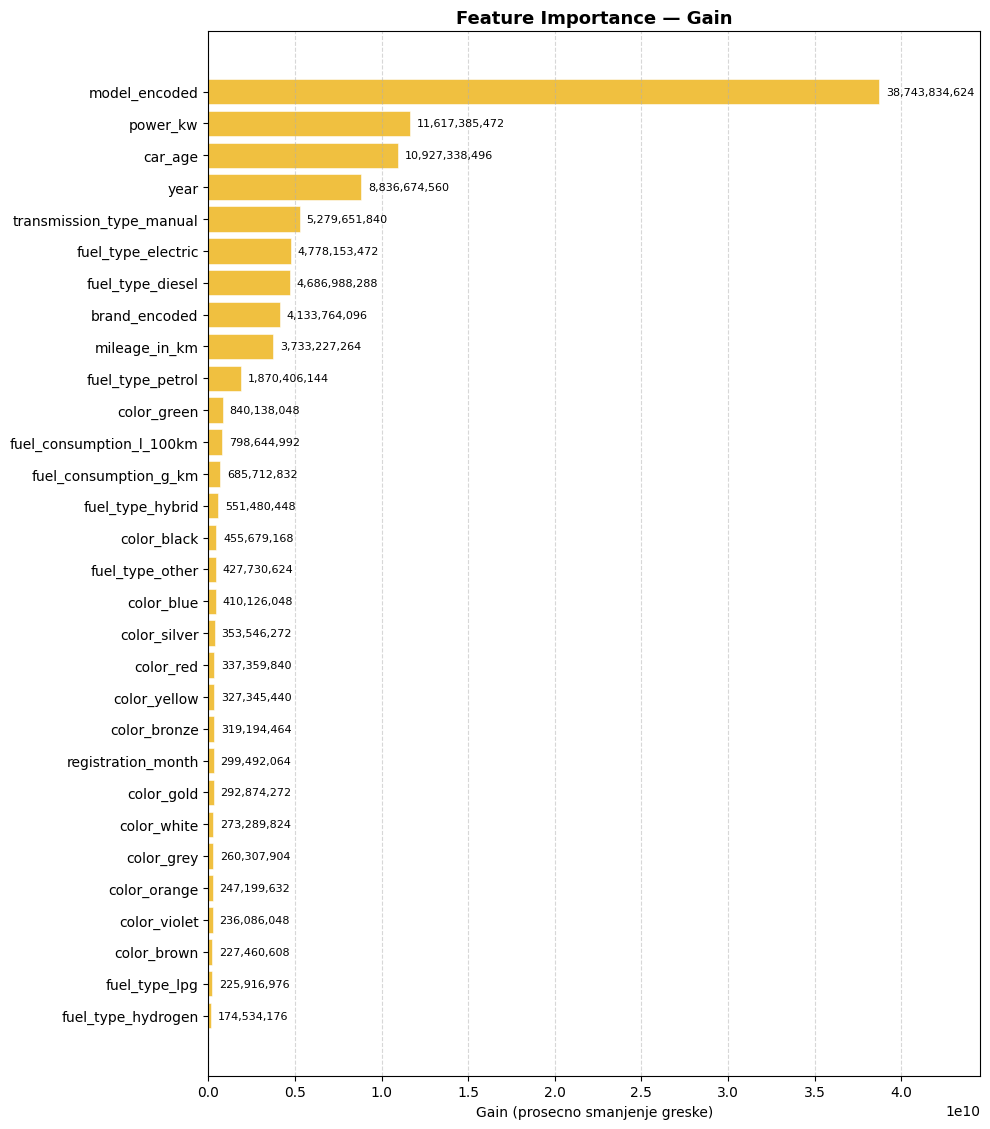


Top 5 najvaznijih featura:
                                  gain
model_encoded             3.874383e+10
power_kw                  1.161739e+10
car_age                   1.092734e+10
year                      8.836675e+09
transmission_type_manual  5.279652e+09


In [27]:
# Celija 6: Feature Importance (gain-based)

best_xgb = random_search.best_estimator_

importance = best_xgb.get_booster().get_score(importance_type='gain')
imp_df = (pd.DataFrame.from_dict(importance, orient='index', columns=['gain'])
            .sort_values('gain', ascending=True))

fig, ax = plt.subplots(figsize=(10, max(5, len(imp_df) * 0.38)))

bars = ax.barh(imp_df.index, imp_df['gain'],
               color='#f0c040', edgecolor='white', linewidth=0.4)

for bar, val in zip(bars, imp_df['gain']):
    ax.text(bar.get_width() + imp_df['gain'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', fontsize=8)

ax.set_title('Feature Importance — Gain', fontsize=13, fontweight='bold')
ax.set_xlabel('Gain (prosecno smanjenje greske)')
ax.set_xlim(0, imp_df['gain'].max() * 1.15)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\nTop 5 najvaznijih featura:")
print(imp_df.tail(5).iloc[::-1].to_string())

### Interpretacija Feature Importance

Feature importance (gain) govori nam koji featurei **najvise doprinose smanjenju greske** pri svakom grananju stabla. Featurei sa visokim gainom su kljucni za predikciju cene, dok featurei sa niskim gainom imaju mali doprinos i potencijalno se mogu ukloniti.

> **Ocekivani nalaz:** `model_encoded`, `power_kw` i `brand_encoded` tipicno dominiraju — model i snaga motora su najjaci prediktori cene polovnog automobila.

## Korak 7: Finalna Evaluacija — MAE, RMSE, R2

Evaluiramo **tuned model** na test setu i poredimo sa baseline-om.

In [28]:
# Celija 7: Evaluacija

y_pred = best_xgb.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("="*45)
print(f"  {'Metrika':<15} {'Baseline':>12} {'Tuned XGB':>12}")
print("-"*45)
print(f"  {'MAE (EUR)':<15} {mae_base:>12,.2f} {mae:>12,.2f}")
print(f"  {'RMSE (EUR)':<15} {rmse_base:>12,.2f} {rmse:>12,.2f}")
print(f"  {'R2':<15} {r2_base:>12.4f} {r2:>12.4f}")
print("="*45)
print(f"\nPoboljsanje MAE:  {mae_base - mae:+,.2f} EUR ({(mae_base - mae)/mae_base*100:+.1f}%)")
print(f"Poboljsanje R2:   {r2 - r2_base:+.4f}")

  Metrika             Baseline    Tuned XGB
---------------------------------------------
  MAE (EUR)           3,293.74     3,003.53
  RMSE (EUR)          7,039.95     6,759.98
  R2                    0.9227       0.9287

Poboljsanje MAE:  +290.21 EUR (+8.8%)
Poboljsanje R2:   +0.0060


## Korak 8: Vizualizacije — Predicted vs Actual + Residual Plot

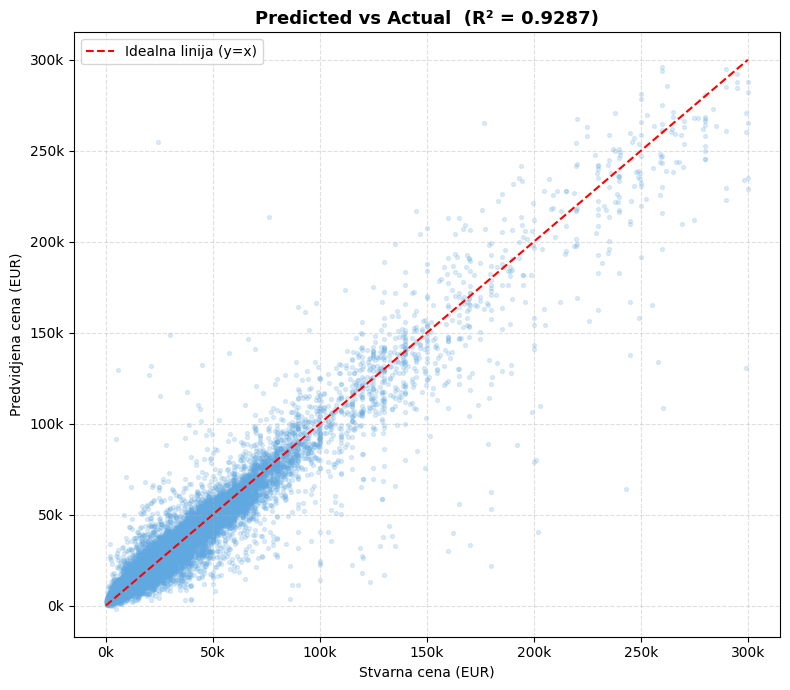

In [29]:
# Celija 8a: Predicted vs Actual

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(y_test, y_pred, alpha=0.2, s=8, color='#60a8e0')

lim = max(y_test.max(), y_pred.max())
ax.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Idealna linija (y=x)')

ax.set_title(f'Predicted vs Actual  (R² = {r2:.4f})', fontsize=13, fontweight='bold')
ax.set_xlabel('Stvarna cena (EUR)')
ax.set_ylabel('Predvidjena cena (EUR)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend()
ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Analiza Predicted vs Actual

Tacke blizu crvene dijagonale znace tacne predikcije. Horizontalno rasipanje u visem cenovnom rangu (iznad 50k EUR) je ocekivano — skupi automobili su redji u datasetu i teze ih je precizno proceniti.

- **Koncentracija oko dijagonale** u opsegu 0–50k EUR — model radi dobro za vecinu automobila
- **Vece rasipanje** iznad 50k EUR — neravnomernost varijansi greske tipicna za cenovne podatke
- Tacke **ispod dijagonale** = model precenjuje; tacke **iznad dijagonale** = model potcenjuje

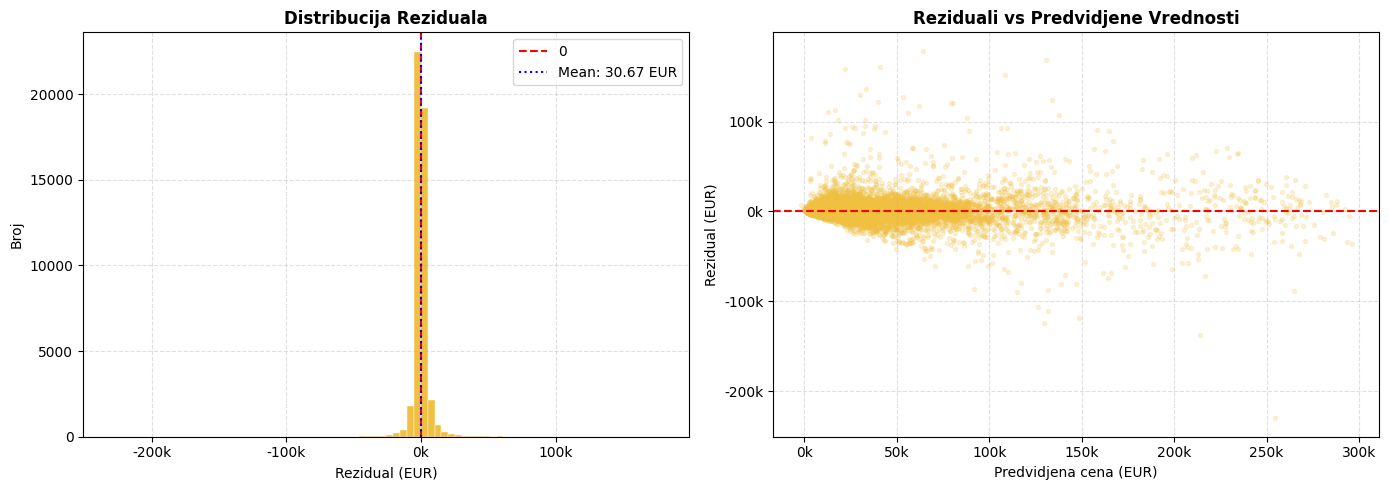

Srednji rezidual: 30.67 EUR
Std reziduala:    6,759.98 EUR

% predikcija unutar +/-2,000 EUR: 59.3%
% predikcija unutar +/-5,000 EUR: 86.5%


In [30]:
# Celija 8b: Residual plot

residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Levi grafikon: Distribucija reziduala
ax = axes[0]
ax.hist(residuals, bins=80, color='#f0c040', edgecolor='white', linewidth=0.3)
ax.axvline(0,                color='red',  linestyle='--', lw=1.5, label='0')
ax.axvline(residuals.mean(), color='blue', linestyle=':',  lw=1.5,
           label=f'Mean: {residuals.mean():,.2f} EUR')
ax.set_title('Distribucija Reziduala', fontsize=12, fontweight='bold')
ax.set_xlabel('Rezidual (EUR)')
ax.set_ylabel('Broj')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend()
ax.grid(linestyle='--', alpha=0.4)

# Desni grafikon: Residuali vs Predvidjene vrijednosti
ax = axes[1]
ax.scatter(y_pred, residuals, alpha=0.2, s=8, color='#f0c040')
ax.axhline(0, color='red', linestyle='--', lw=1.5)
ax.set_title('Reziduali vs Predvidjene Vrednosti', fontsize=12, fontweight='bold')
ax.set_xlabel('Predvidjena cena (EUR)')
ax.set_ylabel('Rezidual (EUR)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"Srednji rezidual: {residuals.mean():.2f} EUR")
print(f"Std reziduala:    {residuals.std():,.2f} EUR")
print(f"\n% predikcija unutar +/-2,000 EUR: {(residuals.abs() <= 2000).mean()*100:.1f}%")
print(f"% predikcija unutar +/-5,000 EUR: {(residuals.abs() <= 5000).mean()*100:.1f}%")

### Analiza Reziduala

Rezidual = stvarna cena - predvidjena cena.

**Levi grafikon — Distribucija Reziduala:**
- Distribucija centrirana oko 0 znaci da model nema sistematsku pristrasnost (bias)
- Standardna devijacija reziduala odgovara RMSE vrijednosti
- Blaga asimetrija sa repom prema negativnim vrednostima tipicna je za cenovne podatke — model ponekad znacajno preceni skuplja vozila

**Desni grafikon — Reziduali vs Predvidjene Vrednosti:**
- Za predikcije do ~25,000 EUR reziduali su gusto koncentrisani oko nule — model radi odlicno u ovom opsegu
- Sa rastom predvidjene cene reziduali se sire — veca varijansa greske kod skupljih automobila

> **Poredjenje sa Ridge-om:** XGBoost bi trebao pokazati znacajno manju neravnomernost varijansi greške od linearnog Ridge modela, jer stabla bolje modeliraju nelinearne odnose izmedju featura i cene.

## Korak 9: Sacuvaj XGBoost Model i Rezultate

In [31]:
# Celija 9: Cuvanje modela i rezultata

# Kreiraj models/ folder ako ne postoji
os.makedirs('../models', exist_ok=True)

# Sacuvaj model
joblib.dump(best_xgb, '../models/xgboost_model.pkl')

# Sacuvaj rezultate u dict (za finalnu tabelu poredjenja modela)
xgb_results = {
    'Model': 'XGBoost Regression',
    'Najbolji parametri': random_search.best_params_,
    'MAE (EUR)': round(mae, 2),
    'RMSE (EUR)': round(rmse, 2),
    'R2': round(r2, 4)
}

print("Model sacuvan u ../models/xgboost_model.pkl")
print("\nFinalni rezultati:")
for k, v in xgb_results.items():
    if k != 'Najbolji parametri':
        print(f"  {k}: {v}")
print("\nNajbolji parametri:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")

Model sacuvan u ../models/xgboost_model.pkl

Finalni rezultati:
  Model: XGBoost Regression
  MAE (EUR): 3003.53
  RMSE (EUR): 6759.98
  R2: 0.9287

Najbolji parametri:
  subsample: 1.0
  reg_lambda: 5.0
  reg_alpha: 0.1
  n_estimators: 800
  min_child_weight: 3
  max_depth: 7
  learning_rate: 0.1
  gamma: 0.1
  colsample_bytree: 0.8


---

## Rezime

| Stavka | Vrednost |
|--------|-----------|
| **Model** | XGBoost Regressor (`reg:squarederror`) |
| **Encoding** | Target Encoding (brand, model) + One-Hot Encoding (transmission, fuel, color) |
| **Skaliranje** | Nije potrebno — stabla su invarijantna na skalu |
| **Tuning** | RandomizedSearchCV, 3-fold CV, 40 iteracija |
| **Evaluacija** | MAE, RMSE, R2 na test setu |

Sacuvani fajlovi:
- `xgboost_model.pkl` — trenirani XGBoost model
- `xgb_feature_importance.png` — gain-based feature importance
- `xgb_pred_vs_actual.png` — predicted vs actual scatter
- `xgb_residuali.png` — distribucija gresaka modela